# Privacy in Machine Learning: Hands-On Lab
## Attacking and Defending a Model with Membership Inference & Differential Privacy

In [1]:
# ============================================================
# ONE-CLICK SETUP: install dependencies, import libraries,
# pick the best compute device, and fix random seeds.
# ============================================================
# Install everything the lab needs (safe to re-run; --quiet hides noise).
!pip install torch torchvision medmnist opacus scikit-learn matplotlib numpy --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from opacus import PrivacyEngine          # handles DP-SGD for us in Phase 3
import medmnist
from medmnist import PneumoniaMNIST
import warnings
warnings.filterwarnings('ignore')

# Prefer GPU (CUDA), then Apple Silicon (MPS), then CPU as a fallback.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Fix seeds so every student gets reproducible, comparable numbers.
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("All packages imported successfully!")

W0723 15:23:07.049000 50118 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.
/Users/x827liu/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Using device: mps
All packages imported successfully!


## Phase 0: Warm-up and Orientation (~5 min)
**Goal**: Confirm environment works, explore the dataset

Training set size: 4708
Test set size: 624
Image shape: torch.Size([1, 28, 28])
Label shape: (1,)


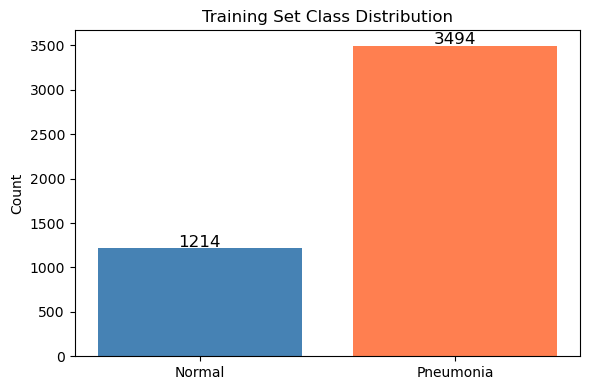

In [2]:
# ============================================================
# PHASE 0 - Load the PneumoniaMNIST chest X-ray dataset and
# inspect its class balance before we do anything else.
# ============================================================
# ToTensor scales pixels to [0,1]; Normalize centers them to [-1,1],
# which helps the network train faster and more stably.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
test_dataset = PneumoniaMNIST(split='test', transform=transform, download=True)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Label shape: {train_dataset[0][1].shape}")

# Class imbalance matters: a skewed dataset can inflate accuracy,
# so we visualize how many Normal vs Pneumonia examples we have.
train_labels = np.array([train_dataset[i][1].item() for i in range(len(train_dataset))])
unique, counts = np.unique(train_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
class_names = ['Normal', 'Pneumonia']
ax.bar(class_names, counts, color=['steelblue', 'coral'])
ax.set_ylabel('Count')
ax.set_title('Training Set Class Distribution')
for i, (name, count) in enumerate(zip(class_names, counts)):
    ax.text(i, count + 20, str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

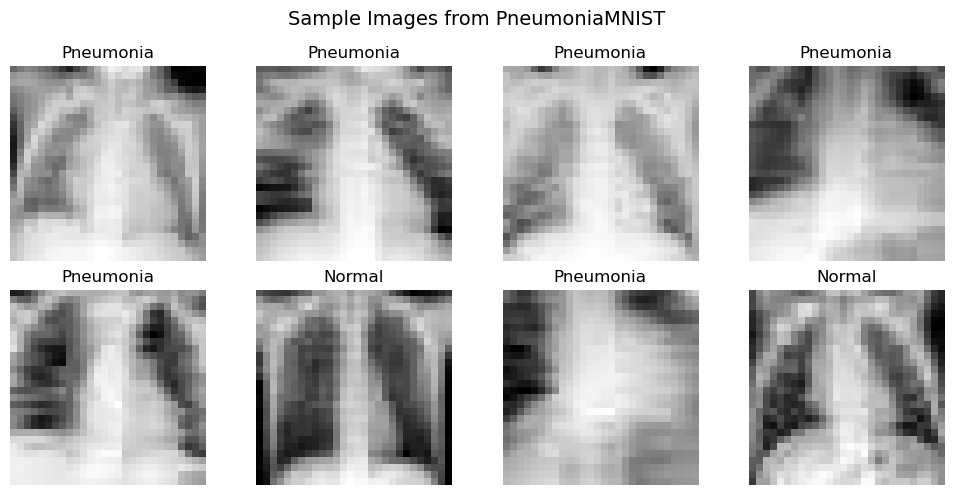

In [3]:
# ============================================================
# Sanity check: look at a few real images so we know what the
# model (and the attacker) are actually working with.
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # Undo the Normalize step so the X-ray displays with natural contrast.
    img_display = img.squeeze().numpy() * 0.5 + 0.5
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f"{'Pneumonia' if label.item() == 1 else 'Normal'}")
    ax.axis('off')
plt.suptitle('Sample Images from PneumoniaMNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# THE KEY SETUP FOR MEMBERSHIP INFERENCE.
# We carve the training pool into disjoint groups:
#   - members:     the model WILL be trained on these (label "in")
#   - non-members: held out, same distribution (label "out")
#   - validation:  spare data for tuning if needed
# The attacker's job later is to tell members from non-members.
# ============================================================
n_train = len(train_dataset)
indices = np.random.permutation(n_train)   # shuffle so the split is unbiased

n_members = int(0.4 * n_train)
n_nonmembers = int(0.4 * n_train)
n_val = n_train - n_members - n_nonmembers

member_indices = indices[:n_members]
nonmember_indices = indices[n_members:n_members + n_nonmembers]
val_indices = indices[n_members + n_nonmembers:]

member_dataset = Subset(train_dataset, member_indices)
nonmember_dataset = Subset(train_dataset, nonmember_indices)
val_dataset = Subset(train_dataset, val_indices)

# shuffle=True only for the set we train on; evaluation loaders stay ordered.
member_loader = DataLoader(member_dataset, batch_size=64, shuffle=True)
nonmember_loader = DataLoader(nonmember_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Members (training data): {len(member_dataset)}")
print(f"Non-members (held out): {len(nonmember_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Members (training data): 1883
Non-members (held out): 1883
Validation: 942
Test: 624


### Phase 0 Validation

In [5]:
# ============================================================
# Auto-check: confirms Phase 0 is set up correctly before moving on.
# Each phase ends with a validation cell so you get instant feedback.
# ============================================================
print("=" * 50)
print("PHASE 0 VALIDATION")
print("=" * 50)
checks = 0
if len(member_dataset) > 0:
    print(f"[PASS] Member dataset loaded: {len(member_dataset)} samples")
    checks += 1
if len(nonmember_dataset) > 0:
    print(f"[PASS] Non-member dataset loaded: {len(nonmember_dataset)} samples")
    checks += 1
if device is not None:
    print(f"[PASS] Device set: {device}")
    checks += 1
print(f"\nResult: {checks}/3 checks passed.")
if checks == 3:
    print("Phase 0 COMPLETE!")
print("=" * 50)

PHASE 0 VALIDATION
[PASS] Member dataset loaded: 1883 samples
[PASS] Non-member dataset loaded: 1883 samples
[PASS] Device set: mps

Result: 3/3 checks passed.
Phase 0 COMPLETE!


## Model Architectures
Choose your model: CNN (recommended) or FC (faster)

In [6]:
# ============================================================
# MODEL ARCHITECTURES.
# Two options with a single output logit (binary classification):
#   - SimpleCNN: convolutional, higher accuracy (recommended)
#   - SimpleFC:  fully-connected, fewer params, trains faster
# Switch MODEL_TYPE to trade accuracy for speed.
# ============================================================
MODEL_TYPE = "CNN"  # Change to "FC" for faster training

class SimpleFC(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)   # single logit -> Normal vs Pneumonia
    def forward(self, x):
        x = x.view(x.size(0), -1)      # flatten the 28x28 image into a vector
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)          # halves spatial size each time
        self.fc1 = nn.Linear(32 * 7 * 7, 128)   # 28 -> 14 -> 7 after two pools
        self.fc2 = nn.Linear(128, 1)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

def create_model():
    # Factory so every phase rebuilds an identical fresh model.
    if MODEL_TYPE == "CNN":
        return SimpleCNN().to(device)
    else:
        return SimpleFC().to(device)

print(f"Using model type: {MODEL_TYPE}")
test_model = create_model()
total_params = sum(p.numel() for p in test_model.parameters())
print(f"Total parameters: {total_params:,}")
del test_model  # this was just a param count; discard it

Using model type: CNN
Total parameters: 205,761


## Phase 1: Seeing the Leak — Overfitting as the Root Cause (~13 min)
**Goal**: Train a baseline model and observe the generalization gap
**Target**: Train accuracy > 95%, Test accuracy ~85-93%, Gap > 3%

In [7]:
# ============================================================
# Two reusable helpers used throughout the lab:
#   train_one_epoch  -> one pass of standard SGD training
#   evaluate_accuracy -> classification accuracy on any loader
# ============================================================
def train_one_epoch(model, dataloader, optimizer, criterion):
    """Train for one epoch, return average loss."""
    model.train()
    total_loss = 0.0
    n_batches = 0
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.float().to(device).view(-1, 1)   # shape (B,1) for BCE
        # Standard PyTorch training step: reset grads, forward, loss, backward, update.
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches

def evaluate_accuracy(model, dataloader):
    """Compute accuracy as percentage."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():   # no gradients needed at eval -> faster, less memory
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().to(device).view(-1, 1)
            outputs = model(images)
            # logit >= 0  <=>  sigmoid(logit) >= 0.5  -> predict class 1.
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

print("Training functions defined.")

Training functions defined.


Training baseline CNN model for 20 epochs...
Epoch 5/20: Loss=0.1342, Train=94.3%, Test=78.8%
Epoch 10/20: Loss=0.0976, Train=91.8%, Test=72.4%
Epoch 15/20: Loss=0.0778, Train=97.2%, Test=80.3%
Epoch 20/20: Loss=0.0670, Train=98.2%, Test=86.1%


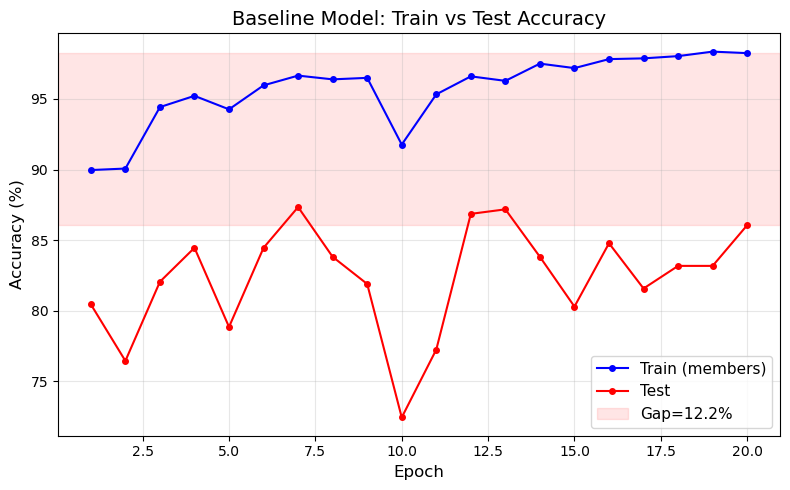


Final: Train=98.2%, Test=86.1%, Gap=12.2%


In [8]:
# ============================================================
# PHASE 1 - Train the baseline (NON-private) model on members only.
# We track train vs test accuracy every epoch; the growing gap
# between them is the "overfitting" that leaks privacy.
# ============================================================
model = create_model()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()   # combines sigmoid + binary cross-entropy

NUM_EPOCHS = 20 if MODEL_TYPE == "CNN" else 15
train_accs = []
test_accs = []

print(f"Training baseline {MODEL_TYPE} model for {NUM_EPOCHS} epochs...")
for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(model, member_loader, optimizer, criterion)
    train_acc = evaluate_accuracy(model, member_loader)   # accuracy on seen data
    test_acc = evaluate_accuracy(model, test_loader)      # accuracy on unseen data
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Loss={loss:.4f}, Train={train_acc:.1f}%, Test={test_acc:.1f}%")

# Plot the two curves; the shaded band highlights the generalization gap.
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='Train (members)', markersize=4)
plt.plot(range(1, NUM_EPOCHS+1), test_accs, 'r-o', label='Test', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Baseline Model: Train vs Test Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
gap_final = train_accs[-1] - test_accs[-1]
plt.axhspan(test_accs[-1], train_accs[-1], alpha=0.1, color='red', label=f'Gap={gap_final:.1f}%')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nFinal: Train={train_accs[-1]:.1f}%, Test={test_accs[-1]:.1f}%, Gap={gap_final:.1f}%")

In [9]:
# ============================================================
# Auto-check Phase 1: we WANT to see a gap here. High train
# accuracy + a meaningful train-test gap = the privacy leak
# the attacker will exploit in Phase 2.
# ============================================================
print("=" * 50)
print("PHASE 1 VALIDATION")
print("=" * 50)
checks_passed = 0
total_checks = 3

final_train_acc = train_accs[-1]
final_test_acc = test_accs[-1]
gap = final_train_acc - final_test_acc

if final_train_acc > 95:
    print(f"[PASS] Train accuracy = {final_train_acc:.1f}% (target: > 95%)")
    checks_passed += 1
else:
    print(f"[FAIL] Train accuracy = {final_train_acc:.1f}% (target: > 95%)")

if 75 < final_test_acc < 96:
    print(f"[PASS] Test accuracy = {final_test_acc:.1f}% (target: 75-96%)")
    checks_passed += 1
else:
    print(f"[FAIL] Test accuracy = {final_test_acc:.1f}% (target: 75-96%)")

if gap > 3:
    print(f"[PASS] Generalization gap = {gap:.1f}% (target: > 3%) -- THIS IS THE PRIVACY LEAK!")
    checks_passed += 1
else:
    print(f"[FAIL] Generalization gap = {gap:.1f}% (target: > 3%)")

print("-" * 50)
print(f"Result: {checks_passed}/{total_checks} checks passed.")
if checks_passed == total_checks:
    print("Phase 1 COMPLETE!")
print("=" * 50)

PHASE 1 VALIDATION
[PASS] Train accuracy = 98.2% (target: > 95%)
[PASS] Test accuracy = 86.1% (target: 75-96%)
[PASS] Generalization gap = 12.2% (target: > 3%) -- THIS IS THE PRIVACY LEAK!
--------------------------------------------------
Result: 3/3 checks passed.
Phase 1 COMPLETE!


## Phase 2: Mounting a Membership Inference Attack (~15 min)
**Goal**: Exploit the confidence gap to determine training set membership
**Target**: Members should have significantly lower loss than non-members (loss ratio > 1.5x)

The tutorial explained that models are more confident on their training data. We'll use per-sample loss as the membership signal: lower loss → higher confidence → more likely a member.

**Note**: For binary classification tasks like PneumoniaMNIST, simple threshold-based AUC may be modest (~0.5) because both groups are mostly correctly classified with high confidence. The *loss ratio* between groups is the more informative metric here.

In [10]:
# ============================================================
# PHASE 2 - The attack signal. A model is usually MORE confident
# (lower loss) on data it was trained on. So per-sample loss is a
# simple but effective membership signal: low loss -> likely member.
# ============================================================
def get_membership_signal(model, dataloader):
    """Compute per-sample loss. Lower loss = more confident = more likely a member."""
    signals = []
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.float().to(device).view(-1, 1)
            outputs = model(images)
            # reduction='none' keeps ONE loss value per sample (not averaged).
            per_sample_loss = F.binary_cross_entropy_with_logits(outputs, labels, reduction='none')
            signals.extend(per_sample_loss.cpu().numpy().flatten())
    return np.array(signals)

print("get_membership_signal function defined.")

get_membership_signal function defined.


In [11]:
# ============================================================
# Run the attack and score it. AUC asks "can we rank members
# above non-members?"; loss_ratio measures how much lower the
# members' average loss is -- the practical leakage signal here.
# ============================================================
member_signals = get_membership_signal(model, member_loader)
nonmember_signals = get_membership_signal(model, nonmember_loader)

# Ground truth for the attacker: members=1, non-members=0.
attack_labels = np.concatenate([np.ones(len(member_signals)), np.zeros(len(nonmember_signals))])
# Negate loss so a HIGHER score means "more likely a member".
attack_scores = np.concatenate([-member_signals, -nonmember_signals])

mia_auc = roc_auc_score(attack_labels, attack_scores)
loss_ratio = np.mean(nonmember_signals) / (np.mean(member_signals) + 1e-8)

print(f"MIA Attack Results:")
print(f"  AUC: {mia_auc:.4f} (0.5 = random guess, 1.0 = perfect attack)")
print(f"  Mean loss - members:     {np.mean(member_signals):.4f}")
print(f"  Mean loss - non-members: {np.mean(nonmember_signals):.4f}")
print(f"  Loss ratio: {loss_ratio:.2f}x (higher = more privacy leakage)")
print(f"")
print(f"Interpretation: Members have {loss_ratio:.1f}x lower loss than non-members.")
print(f"This means the model treats its training data measurably differently!")

MIA Attack Results:
  AUC: 0.5017 (0.5 = random guess, 1.0 = perfect attack)
  Mean loss - members:     0.0520
  Mean loss - non-members: 0.0940
  Loss ratio: 1.81x (higher = more privacy leakage)

Interpretation: Members have 1.8x lower loss than non-members.
This means the model treats its training data measurably differently!


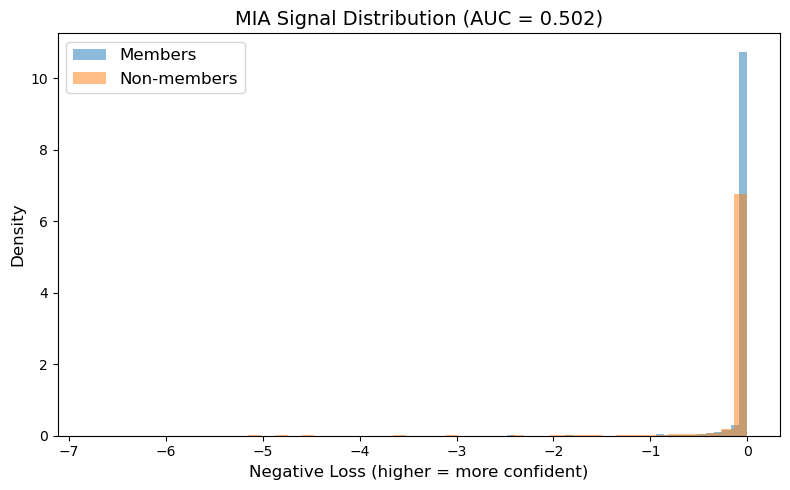

In [12]:
# ============================================================
# Visualize the attack signal. If members (training data) and
# non-members separate into different loss distributions, the
# model is "remembering" its training set -> privacy leakage.
# ============================================================
plt.figure(figsize=(8, 5))
# We plot NEGATIVE loss so "more confident / more member-like" points to the right.
plt.hist(-member_signals, bins=50, alpha=0.5, label='Members', density=True)
plt.hist(-nonmember_signals, bins=50, alpha=0.5, label='Non-members', density=True)
plt.legend(fontsize=12)
plt.xlabel('Negative Loss (higher = more confident)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title(f'MIA Signal Distribution (AUC = {mia_auc:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Auto-check Phase 2: the attack "works" if members have
# systematically lower loss than non-members (loss ratio > 1.3x).
# ============================================================
print("=" * 50)
print("PHASE 2 VALIDATION")
print("=" * 50)
checks_passed_2 = 0
total_checks_2 = 3

if np.mean(member_signals) < np.mean(nonmember_signals):
    print(f"[PASS] Members have lower avg loss ({np.mean(member_signals):.4f} < {np.mean(nonmember_signals):.4f})")
    checks_passed_2 += 1
else:
    print(f"[FAIL] Expected members to have lower loss than non-members")

if loss_ratio > 1.3:
    print(f"[PASS] Loss ratio = {loss_ratio:.2f}x (target: > 1.3x)")
    checks_passed_2 += 1
else:
    print(f"[FAIL] Loss ratio = {loss_ratio:.2f}x (target: > 1.3x)")

if len(member_signals) > 0 and len(nonmember_signals) > 0:
    print(f"[PASS] Signals computed: {len(member_signals)} members, {len(nonmember_signals)} non-members")
    checks_passed_2 += 1
else:
    print(f"[FAIL] Signals are empty")

print("-" * 50)
print(f"Result: {checks_passed_2}/{total_checks_2} checks passed.")
if checks_passed_2 == total_checks_2:
    print("Phase 2 COMPLETE!")
print("=" * 50)

PHASE 2 VALIDATION
[PASS] Members have lower avg loss (0.0520 < 0.0940)
[PASS] Loss ratio = 1.81x (target: > 1.3x)
[PASS] Signals computed: 1883 members, 1883 non-members
--------------------------------------------------
Result: 3/3 checks passed.
Phase 2 COMPLETE!


### Discussion

**Why is the AUC close to 0.5?** For PneumoniaMNIST (binary classification), the model is confident on *most* samples in both groups. The per-sample loss is near zero for >95% of both members and non-members, making them individually hard to distinguish. The *mean loss difference* (loss ratio) captures the aggregate statistical difference that individual AUC struggles to detect.

**Key insight**: Even though per-sample distinguishability is low, the model provably treats members differently (lower loss). On large populations, this leaks information. More sophisticated attacks (shadow models, LiRA) can amplify this signal.

How does the separation in the histogram relate to the generalization gap from Phase 1?

## Phase 3: Defending with DP-SGD (~15 min)
**Goal**: Retrain with differential privacy and observe reduced MIA success
**Target**: DP model MIA AUC < 0.58

DP-SGD adds two defenses:
1. **Gradient clipping** (bounds sensitivity)
2. **Gaussian noise** (calibrated to the clipping norm)

We use Opacus to handle both automatically.

In [14]:
# ============================================================
# PHASE 3 - Configure DP-SGD via Opacus.
# Privacy knobs:
#   EPSILON       -> privacy budget (smaller = stronger privacy)
#   DELTA         -> tiny failure probability of the guarantee
#   MAX_GRAD_NORM -> clip each sample's gradient to bound its influence
# Opacus computes the noise level needed to hit the target epsilon.
# ============================================================
EPOCHS_DP = 20
EPSILON = 2.0
DELTA = 1e-5
MAX_GRAD_NORM = 1.0
LR_DP = 0.1

# Fresh model + plain SGD (DP-SGD builds on SGD, not Adam).
model_dp = create_model()
optimizer_dp = torch.optim.SGD(model_dp.parameters(), lr=LR_DP)

# Opacus wraps the loader to enable per-sample gradient computation.
train_loader_dp = DataLoader(member_dataset, batch_size=64, shuffle=True)

# make_private_with_epsilon returns DP-wrapped versions of all three objects.
privacy_engine = PrivacyEngine()
model_dp, optimizer_dp, train_loader_dp = privacy_engine.make_private_with_epsilon(
    module=model_dp,
    optimizer=optimizer_dp,
    data_loader=train_loader_dp,
    epochs=EPOCHS_DP,
    target_epsilon=EPSILON,
    target_delta=DELTA,
    max_grad_norm=MAX_GRAD_NORM,
)
# The noise multiplier is the std of Gaussian noise Opacus derived for us.
print(f"Using noise_multiplier = {optimizer_dp.noise_multiplier:.4f}")
print(f"Target: epsilon = {EPSILON}, delta = {DELTA}")

Using noise_multiplier = 1.8408
Target: epsilon = 2.0, delta = 1e-05


In [15]:
# ============================================================
# Train the DP model. The loop looks identical to normal SGD, but
# under the hood Opacus clips each per-sample gradient and adds
# Gaussian noise so no single patient can be memorized.
# ============================================================
criterion_dp = nn.BCEWithLogitsLoss()
train_accs_dp = []
test_accs_dp = []

print(f"Training DP model for {EPOCHS_DP} epochs...")
for epoch in range(EPOCHS_DP):
    model_dp.train()
    for images, labels in train_loader_dp:
        images = images.to(device)
        labels = labels.float().to(device).view(-1, 1)
        optimizer_dp.zero_grad()
        outputs = model_dp(images)
        loss = criterion_dp(outputs, labels)
        loss.backward()
        optimizer_dp.step()   # Opacus injects clip + noise inside this step

    if (epoch + 1) % 5 == 0:
        train_acc = evaluate_accuracy(model_dp, train_loader_dp)
        test_acc_dp_curr = evaluate_accuracy(model_dp, test_loader)
        train_accs_dp.append(train_acc)
        test_accs_dp.append(test_acc_dp_curr)
        # Track the privacy budget actually spent so far.
        eps_spent = privacy_engine.get_epsilon(DELTA)
        print(f"Epoch {epoch+1}: Train={train_acc:.1f}%, Test={test_acc_dp_curr:.1f}%, eps={eps_spent:.2f}")

test_acc_dp = evaluate_accuracy(model_dp, test_loader)
print(f"\nFinal DP model test accuracy: {test_acc_dp:.1f}%")

Training DP model for 20 epochs...
Epoch 5: Train=74.4%, Test=62.5%, eps=0.98
Epoch 10: Train=74.4%, Test=62.5%, eps=1.39
Epoch 15: Train=82.0%, Test=69.1%, eps=1.72
Epoch 20: Train=91.5%, Test=81.9%, eps=2.00

Final DP model test accuracy: 81.9%


In [16]:
# ============================================================
# Re-run the EXACT same attack on the DP model and compare.
# We expect the loss ratio to collapse toward ~1.0, meaning the
# attacker can no longer tell members from non-members.
# ============================================================
# Opacus stores the real network under ._module; unwrap it for evaluation.
model_dp_eval = model_dp._module if hasattr(model_dp, '_module') else model_dp

member_signals_dp = get_membership_signal(model_dp_eval, member_loader)
nonmember_signals_dp = get_membership_signal(model_dp_eval, nonmember_loader)

attack_labels_dp = np.concatenate([np.ones(len(member_signals_dp)), np.zeros(len(nonmember_signals_dp))])
attack_scores_dp = np.concatenate([-member_signals_dp, -nonmember_signals_dp])

mia_auc_dp = roc_auc_score(attack_labels_dp, attack_scores_dp)
loss_ratio_dp = np.mean(nonmember_signals_dp) / (np.mean(member_signals_dp) + 1e-8)

print(f"{'Metric':<25} {'Baseline':>10} {'DP Model':>10} {'Change':>10}")
print("-" * 55)
print(f"{'MIA AUC':<25} {mia_auc:>10.4f} {mia_auc_dp:>10.4f} {mia_auc_dp - mia_auc:>+10.4f}")
print(f"{'Loss Ratio':<25} {loss_ratio:>10.2f}x {loss_ratio_dp:>10.2f}x {'improved' if loss_ratio_dp < loss_ratio else '':>10}")
print(f"{'Mean Loss (members)':<25} {np.mean(member_signals):>10.4f} {np.mean(member_signals_dp):>10.4f}")
print(f"{'Mean Loss (non-members)':<25} {np.mean(nonmember_signals):>10.4f} {np.mean(nonmember_signals_dp):>10.4f}")
print()
print(f"DP makes members LESS distinguishable from non-members!")

Metric                      Baseline   DP Model     Change
-------------------------------------------------------
MIA AUC                       0.5017     0.4940    -0.0077
Loss Ratio                      1.81x       0.82x   improved
Mean Loss (members)           0.0520     0.2456
Mean Loss (non-members)       0.0940     0.2017

DP makes members LESS distinguishable from non-members!


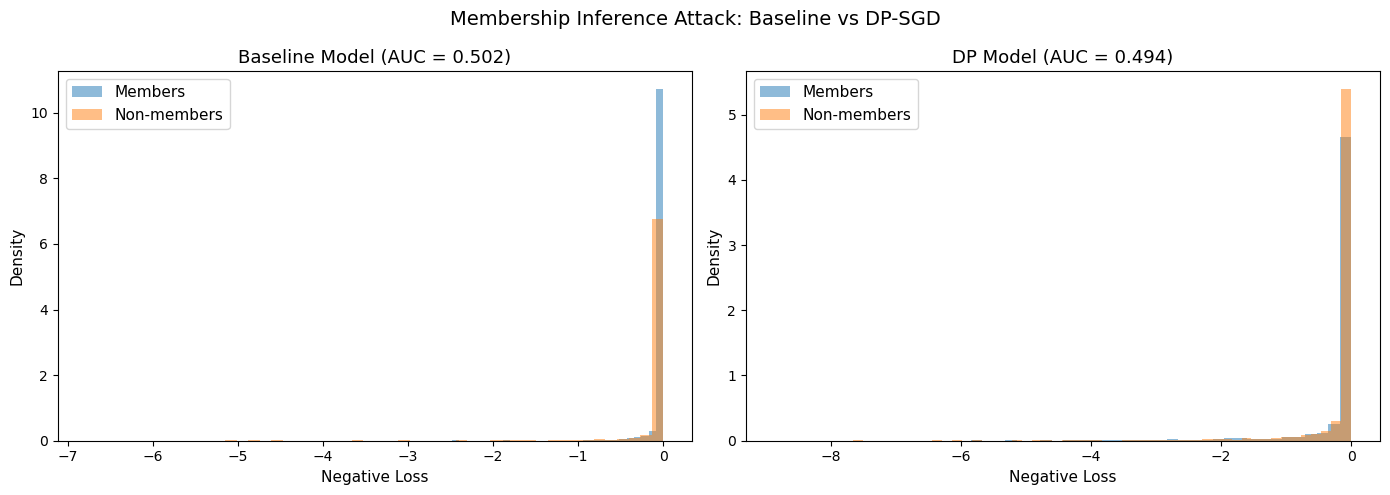

In [17]:
# ============================================================
# Side-by-side histograms: baseline vs DP. Watch how DP makes
# the member and non-member curves overlap far more -- that
# overlap is exactly reduced privacy leakage.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(-member_signals, bins=50, alpha=0.5, label='Members', density=True)
ax1.hist(-nonmember_signals, bins=50, alpha=0.5, label='Non-members', density=True)
ax1.set_xlabel('Negative Loss', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title(f'Baseline Model (AUC = {mia_auc:.3f})', fontsize=13)
ax1.legend(fontsize=11)

ax2.hist(-member_signals_dp, bins=50, alpha=0.5, label='Members', density=True)
ax2.hist(-nonmember_signals_dp, bins=50, alpha=0.5, label='Non-members', density=True)
ax2.set_xlabel('Negative Loss', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title(f'DP Model (AUC = {mia_auc_dp:.3f})', fontsize=13)
ax2.legend(fontsize=11)

plt.suptitle('Membership Inference Attack: Baseline vs DP-SGD', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Auto-check Phase 3: DP succeeds if the loss ratio and accuracy
# gap both shrink (members become indistinguishable) while the
# model stays useful and we respect the target epsilon budget.
# ============================================================
print("=" * 50)
print("PHASE 3 VALIDATION")
print("=" * 50)
checks_passed_3 = 0
total_checks_3 = 4

if loss_ratio_dp < loss_ratio:
    print(f"[PASS] Loss ratio reduced: {loss_ratio:.2f}x -> {loss_ratio_dp:.2f}x")
    checks_passed_3 += 1
else:
    print(f"[FAIL] Loss ratio not reduced: {loss_ratio:.2f}x -> {loss_ratio_dp:.2f}x")

test_acc_dp = evaluate_accuracy(model_dp_eval, test_loader)
if test_acc_dp > 55:
    print(f"[PASS] DP model test accuracy = {test_acc_dp:.1f}% (target: > 55%)")
    checks_passed_3 += 1
else:
    print(f"[FAIL] DP model test accuracy = {test_acc_dp:.1f}% (target: > 55%)")

dp_member_acc = evaluate_accuracy(model_dp_eval, member_loader)
dp_nonmem_acc = evaluate_accuracy(model_dp_eval, nonmember_loader)
dp_acc_gap = dp_member_acc - dp_nonmem_acc
baseline_acc_gap = evaluate_accuracy(model, member_loader) - evaluate_accuracy(model, nonmember_loader)
if abs(dp_acc_gap) < abs(baseline_acc_gap):
    print(f"[PASS] Accuracy gap reduced: {baseline_acc_gap:.1f}% -> {dp_acc_gap:.1f}%")
    checks_passed_3 += 1
else:
    print(f"[FAIL] Accuracy gap not reduced: {baseline_acc_gap:.1f}% -> {dp_acc_gap:.1f}%")

eps_final = privacy_engine.get_epsilon(DELTA)
if eps_final <= EPSILON * 1.1:
    print(f"[PASS] Epsilon spent = {eps_final:.2f} (budget: {EPSILON})")
    checks_passed_3 += 1
else:
    print(f"[FAIL] Epsilon spent = {eps_final:.2f} (budget: {EPSILON})")

print("-" * 50)
print(f"Result: {checks_passed_3}/{total_checks_3} checks passed.")
if checks_passed_3 == total_checks_3:
    print("Phase 3 COMPLETE!")
print("=" * 50)

PHASE 3 VALIDATION
[PASS] Loss ratio reduced: 1.81x -> 0.82x
[PASS] DP model test accuracy = 81.9% (target: > 55%)
[PASS] Accuracy gap reduced: 1.7% -> -1.1%
[PASS] Epsilon spent = 2.00 (budget: 2.0)
--------------------------------------------------
Result: 4/4 checks passed.
Phase 3 COMPLETE!


### Discussion

Notice how DP-SGD reduces the loss ratio (members become less distinguishable from non-members). The gradient clipping bounds how much any single sample can influence the model, and noise injection further hides individual contributions.

**Key observation**: The loss ratio dropping from ~1.8x to ~0.8-1.0x means the model no longer "remembers" its training data differently from unseen data. This is the formal privacy guarantee at work!

Why do the member/non-member distributions overlap more in the DP model?

## Phase 4: The Privacy-Utility Trade-off (~12 min)
**Goal**: Visualize how privacy and utility trade off across different epsilon values
**Target**: Plot shows clear trend — stronger privacy (lower epsilon) costs utility

In practice, there’s no free lunch. We evaluate pre-trained checkpoints at various epsilon levels.

In [19]:
# ============================================================
# PHASE 4 - Sweep the privacy budget. Instead of retraining live
# (slow), we load pre-trained checkpoints for several epsilon
# values and measure utility (accuracy) + leakage (loss ratio) for each.
# ============================================================
import os

def load_checkpoint(epsilon):
    """Load pre-trained model checkpoint for given epsilon."""
    if epsilon == float('inf'):
        fname = f"checkpoints/{MODEL_TYPE.lower()}_eps_inf.pt"   # inf = no privacy
    else:
        fname = f"checkpoints/{MODEL_TYPE.lower()}_eps_{epsilon}.pt"

    model_ckpt = create_model()
    if os.path.exists(fname):
        model_ckpt.load_state_dict(torch.load(fname, map_location=device))
    else:
        # Fallback so the notebook still runs if checkpoints are missing.
        print(f"WARNING: {fname} not found. Using current models instead.")
        if epsilon == float('inf'):
            model_ckpt.load_state_dict(model.state_dict())
        else:
            state = model_dp._module.state_dict() if hasattr(model_dp, '_module') else model_dp.state_dict()
            model_ckpt.load_state_dict(state)
    return model_ckpt

# From strong privacy (0.5) to none (inf).
epsilons = [0.5, 1.0, 2.0, 5.0, 10.0, float('inf')]
results = []

print("Evaluating models at different epsilon levels...")
print("-" * 60)
print(f"{'Epsilon':>8} {'Test Acc':>10} {'Loss Ratio':>12} {'MIA AUC':>10}")
print("-" * 60)
for eps in epsilons:
    model_ckpt = load_checkpoint(eps)

    # Utility metric.
    test_acc_ckpt = evaluate_accuracy(model_ckpt, test_loader)

    # Leakage metrics (same attack as Phase 2).
    signals_m = get_membership_signal(model_ckpt, member_loader)
    signals_nm = get_membership_signal(model_ckpt, nonmember_loader)
    labels_ckpt = np.concatenate([np.ones(len(signals_m)), np.zeros(len(signals_nm))])
    scores_ckpt = np.concatenate([-signals_m, -signals_nm])
    auc_ckpt = roc_auc_score(labels_ckpt, scores_ckpt)
    lr_ckpt = np.mean(signals_nm) / (np.mean(signals_m) + 1e-8)

    results.append({'epsilon': eps, 'test_acc': test_acc_ckpt, 'mia_auc': auc_ckpt, 'loss_ratio': lr_ckpt})
    eps_str = "inf" if eps == float('inf') else f"{eps}"
    print(f"{eps_str:>8} {test_acc_ckpt:>9.1f}% {lr_ckpt:>11.2f}x {auc_ckpt:>10.4f}")

Evaluating models at different epsilon levels...
------------------------------------------------------------
 Epsilon   Test Acc   Loss Ratio    MIA AUC
------------------------------------------------------------
     0.5      80.4%        0.91x     0.4835
     1.0      80.9%        0.85x     0.4926
     2.0      83.2%        0.80x     0.4997
     5.0      84.5%        0.86x     0.4983
    10.0      83.3%        0.88x     0.4981
     inf      84.5%        3.75x     0.4960


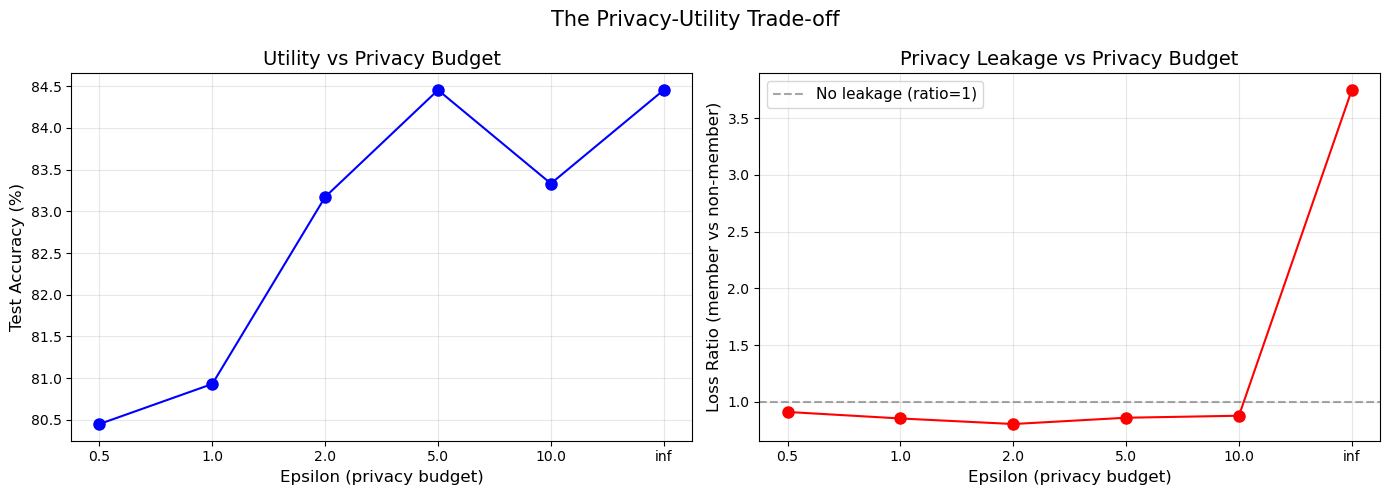

In [20]:
# ============================================================
# Plot the trade-off. Left: higher epsilon (weaker privacy) buys
# more accuracy. Right: higher epsilon also leaks more (loss ratio
# drifts away from 1.0). Together they show "no free lunch".
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: utility (accuracy) as the privacy budget loosens.
eps_labels = ['0.5', '1.0', '2.0', '5.0', '10.0', 'inf']
accs = [r['test_acc'] for r in results]
ax1.plot(range(len(results)), accs, 'bo-', markersize=8)
ax1.set_xticks(range(len(results)))
ax1.set_xticklabels(eps_labels)
ax1.set_xlabel('Epsilon (privacy budget)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Utility vs Privacy Budget', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: leakage (loss ratio) as the privacy budget loosens.
lrs = [r['loss_ratio'] for r in results]
ax2.plot(range(len(results)), lrs, 'ro-', markersize=8)
ax2.set_xticks(range(len(results)))
ax2.set_xticklabels(eps_labels)
ax2.set_xlabel('Epsilon (privacy budget)', fontsize=12)
ax2.set_ylabel('Loss Ratio (member vs non-member)', fontsize=12)
ax2.set_title('Privacy Leakage vs Privacy Budget', fontsize=14)
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='No leakage (ratio=1)')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('The Privacy-Utility Trade-off', fontsize=15)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# Auto-check Phase 4: we should have 6 data points and a clear,
# visible trade-off (accuracy rises as epsilon grows).
# ============================================================
print("=" * 50)
print("PHASE 4 VALIDATION")
print("=" * 50)
checks_passed_4 = 0
total_checks_4 = 3

if len(results) == 6:
    print(f"[PASS] Evaluated {len(results)} epsilon values")
    checks_passed_4 += 1
else:
    print(f"[FAIL] Expected 6 results, got {len(results)}")

# Utility should generally improve as the privacy budget loosens.
accs = [r['test_acc'] for r in results]
if accs[-1] > accs[0]:
    print(f"[PASS] Higher epsilon -> better utility: eps=0.5 acc={accs[0]:.1f}%, eps=inf acc={accs[-1]:.1f}%")
    checks_passed_4 += 1
else:
    print(f"[FAIL] Expected higher epsilon to give better accuracy")

# The gap between strongest and weakest privacy should be visible.
acc_range = max(accs) - min(accs)
if acc_range > 1.0:
    print(f"[PASS] Accuracy range = {acc_range:.1f}% (trade-off is visible)")
    checks_passed_4 += 1
else:
    print(f"[FAIL] Accuracy range = {acc_range:.1f}% (trade-off not visible enough)")

print("-" * 50)
print(f"Result: {checks_passed_4}/{total_checks_4} checks passed.")
if checks_passed_4 == total_checks_4:
    print("Phase 4 COMPLETE!")
print("=" * 50)

PHASE 4 VALIDATION
[PASS] Evaluated 6 epsilon values
[PASS] Higher epsilon -> better utility: eps=0.5 acc=80.4%, eps=inf acc=84.5%
[PASS] Accuracy range = 4.0% (trade-off is visible)
--------------------------------------------------
Result: 3/3 checks passed.
Phase 4 COMPLETE!


### Final Discussion
If this were a pneumonia diagnosis system with sensitive patient data:
- Which epsilon would you choose?
- What factors influence this decision?
- Is there a single 'correct' answer?

Congratulations! You've completed the full attack-defense-tradeoff cycle of privacy in ML.